# MAX Auxetic Classification — Chemistry Only

## هدف
پیش‌بینی **فقط علامت ضریب پواسون کمینه** برای فازهای MAX:

\[
y=\mathbb{1}(\nu_{min}<0)
\]

این نوت‌بوک عمداً وارد پیش‌بینی عددی $\nu_{min}$، Cij یا ساختار POSCAR نمی‌شود. ورودی مدل‌ها فقط **ویژگی‌های شیمیایی/ترکیبی** است.

### نکته روش‌شناختی
- ارزیابی اصلی با **Out-of-Fold / Stratified 5-Fold CV** انجام می‌شود.
- برای آستانه احتمال، تنظیم threshold فقط در حلقه داخلی هر fold انجام می‌شود تا leakage ایجاد نشود.
- Accuracy معیار اصلی است، اما Recall برای مواد auxetic، F1، ROC-AUC و PR-AUC هم گزارش می‌شوند.
- چند مدل مستقل و یک soft-voting/average ensemble مقایسه می‌شوند.
- هیچ داده ساختاری از POSCAR استفاده نمی‌شود.

> این نوت‌بوک قرار نیست عدد خاصی مثل 98٪ را از پیش تضمین کند. عدد نهایی باید از OOF واقعی به دست آید.



In [66]:
# ============================================================
# 0) Installation & imports
# ============================================================
!pip install -q xgboost lightgbm catboost matminer pymatgen scikit-learn scipy seaborn

import os, re, json, warnings, sys, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report,
    balanced_accuracy_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import (
    ExtraTreesClassifier, RandomForestClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier,
    RandomForestClassifier, VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import os

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

RANDOM_STATE=42
N_JOBS=2

CANDIDATE_DIRS=[
    "/kaggle/input/datasets/metisa81/elastic-properties",
    "/mnt/data"
]




DATA_DIR=next((p for p in CANDIDATE_DIRS if os.path.exists(os.path.join(p,"vaspkit_output.json"))),None)
if DATA_DIR is None:
    raise FileNotFoundError("vaspkit_output.json not found. Set DATA_DIR manually.")
OUT_DIR="/kaggle/working/v6" if os.path.exists("/kaggle") else "/mnt/data"
os.makedirs(OUT_DIR,exist_ok=True)

print("✓ DATA_DIR:",DATA_DIR)
print("✓ OUT_DIR:",OUT_DIR)
print("✓ Python:",sys.version.split()[0])



✓ DATA_DIR: /kaggle/input/datasets/metisa81/elastic-properties
✓ OUT_DIR: /kaggle/working/v6
✓ Python: 3.12.13


## 1. ساخت دیتاست شیمیایی از VASPKIT

هدف، تعریف دقیق برچسب است:

- `Auxetic = 1` اگر $\nu_{min}<0$
- `Auxetic = 0` اگر $\nu_{min}\ge0$

ویژگی‌ها فقط از سه سایت شیمیایی M/A/X ساخته می‌شوند.



In [67]:
def parse_formula(name):
    toks=re.findall(r'[A-Z][a-z]?',name)
    if len(toks)!=3:
        raise ValueError(f"Unexpected MAX formula: {name} -> {toks}")
    return toks

with open(os.path.join(DATA_DIR,"vaspkit_output.json"),"r") as f:
    vk=json.load(f)
ptable=pd.read_csv(os.path.join(DATA_DIR,"ptable2.csv")).set_index("symbol")

ELEMENT_COLS=[
    "atomic_number","atomic_radius","covalent_radius_cordero",
    "atomic_weight","density","melting_point","boiling_point",
    "en_pauling","electron_affinity","ionization_energy",
    "valance_main","group_id","period","dipole_polarizability",
    "atomic_volume","vdw_radius"
]

rows=[]
for name,d in tqdm(vk.items(),desc="Building chemistry-only dataset"):
    try:
        stable=d.get("Additional_Properties",{}).get("Mechanical_Stability") == "Stable"
        aniso=d.get("Anisotropic_Mechanical_Properties",{}).get("Poisson's_Ratio_v")
        if not stable or not isinstance(aniso,dict) or "Min" not in aniso:
            continue
        m,a,x=parse_formula(name)
        if any(e not in ptable.index for e in (m,a,x)):
            continue
        r={"material":name,"M":m,"A":a,"X":x,"nu_min":float(aniso["Min"])}
        for site,el in (("M",m),("A",a),("X",x)):
            for c in ELEMENT_COLS:
                r[f"{site}_{c}"]=float(ptable.loc[el,c])
        r["en_diff_MX"]=r["M_en_pauling"]-r["X_en_pauling"]
        r["en_diff_MA"]=r["M_en_pauling"]-r["A_en_pauling"]
        r["en_diff_AX"]=r["A_en_pauling"]-r["X_en_pauling"]
        r["radius_ratio_AX"]=r["A_covalent_radius_cordero"]/r["X_covalent_radius_cordero"]
        r["radius_ratio_MX"]=r["M_covalent_radius_cordero"]/r["X_covalent_radius_cordero"]
        r["radius_ratio_MA"]=r["M_covalent_radius_cordero"]/r["A_covalent_radius_cordero"]
        r["M_enpauling_x_Mgroup"]=r["M_en_pauling"]*r["M_group_id"]
        r["M_ionize_x_A_valance"]=r["M_ionization_energy"]*r["A_valance_main"]
        r["endiffMX_x_radiusratio"]=r["en_diff_MX"]*r["radius_ratio_AX"]
        r["Mgroup_x_Agroup"]=r["M_group_id"]*r["A_group_id"]
        r["Menpauling_x_Aenpauling"]=r["M_en_pauling"]*r["A_en_pauling"]
        r["VEC"]=(2*r["M_group_id"]+r["A_valance_main"]+r["X_valance_main"])/4
        r["VEC_x_endiffMX"]=r["VEC"]*r["en_diff_MX"]
        rows.append(r)
    except Exception:
        continue

df=pd.DataFrame(rows).set_index("material")
CHEM_FEATURES=[c for c in df.columns if c.startswith(("M_","A_","X_")) or c in [
    "en_diff_MX","en_diff_MA","en_diff_AX","radius_ratio_AX","radius_ratio_MX","radius_ratio_MA",
    "M_enpauling_x_Mgroup","M_ionize_x_A_valance","endiffMX_x_radiusratio","Mgroup_x_Agroup",
    "Menpauling_x_Aenpauling","VEC","VEC_x_endiffMX"]]
X_chem=df[CHEM_FEATURES].replace([np.inf,-np.inf],np.nan)
y=(df["nu_min"].values<0).astype(int)
print("Dataset:",len(df))
print("Chemical features before Magpie:",len(CHEM_FEATURES))
print("Auxetic:",int(y.sum()),"/",len(y),f"({100*y.mean():.2f}%)")



Building chemistry-only dataset:   0%|          | 0/553 [00:00<?, ?it/s]

Dataset: 547
Chemical features before Magpie: 61
Auxetic: 134 / 547 (24.50%)


## 2. Rich chemistry features: Magpie + Stoichiometry + Valence + IonProperty



In [68]:
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty, Stoichiometry, ValenceOrbital, IonProperty

magpie=ElementProperty.from_preset("magpie")
stoich=Stoichiometry()
valence=ValenceOrbital()
ion=IonProperty()
rich_rows=[]
for material in tqdm(df.index,desc="Matminer"):
    out={"material":material}
    comp=Composition(material)
    for prefix,feat in (("Magpie",magpie),("Stoich",stoich),("Valence",valence),("Ion",ion)):
        try:
            vals=feat.featurize(comp)
            for lab,val in zip(feat.feature_labels(),vals):
                out[f"{prefix}_{lab}"]=float(val) if np.isfinite(val) else np.nan
        except Exception:
            pass
    rich_rows.append(out)
rich=pd.DataFrame(rich_rows).set_index("material")
X=pd.concat([X_chem,rich],axis=1)
X=X.loc[:,~X.columns.duplicated()]
X=X.loc[:,X.nunique(dropna=False)>1]
X=X.replace([np.inf,-np.inf],np.nan)
X=X.loc[:,X.isna().mean()<0.35]
print("Final chemistry-only feature count:",X.shape[1])



Matminer:   0%|          | 0/547 [00:00<?, ?it/s]

Final chemistry-only feature count: 186


## 3. نمودارهای اکتشافی زیبا برای خود دیتاست



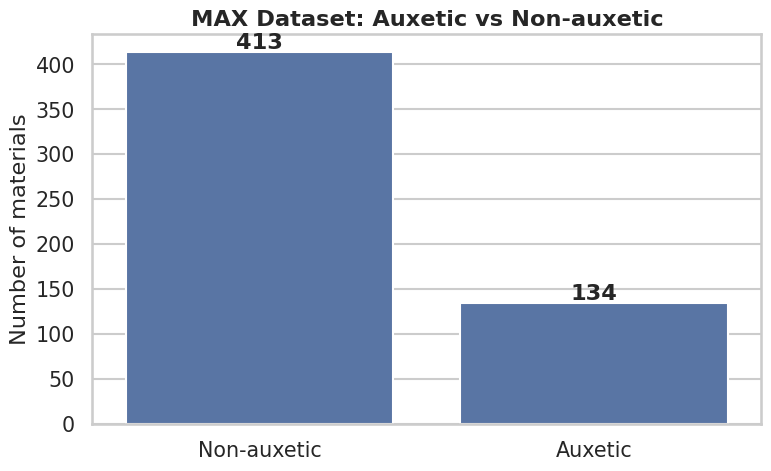

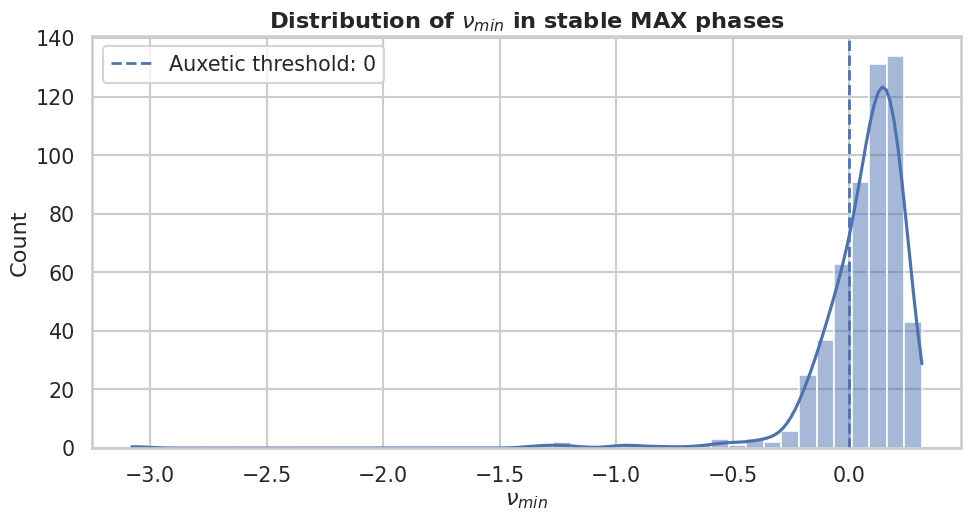

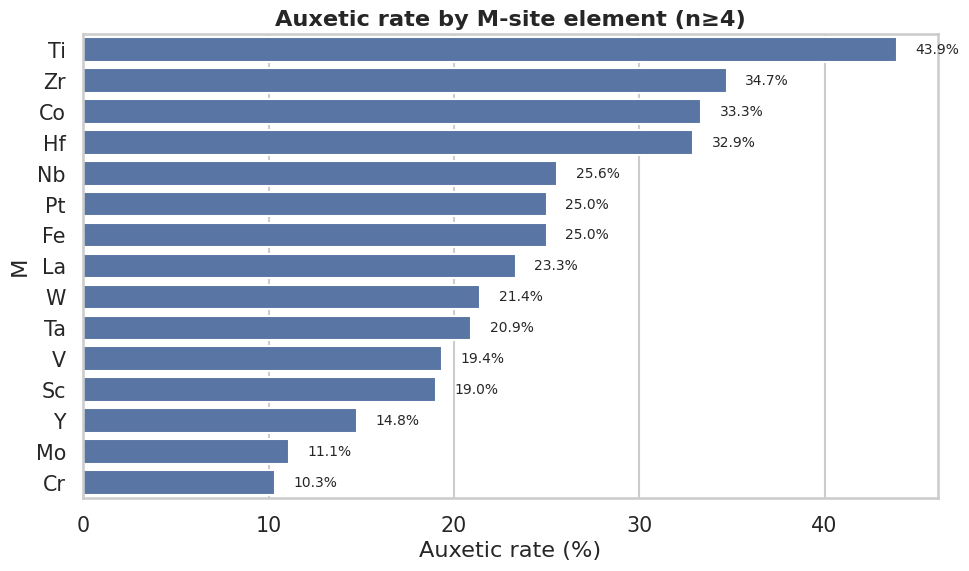

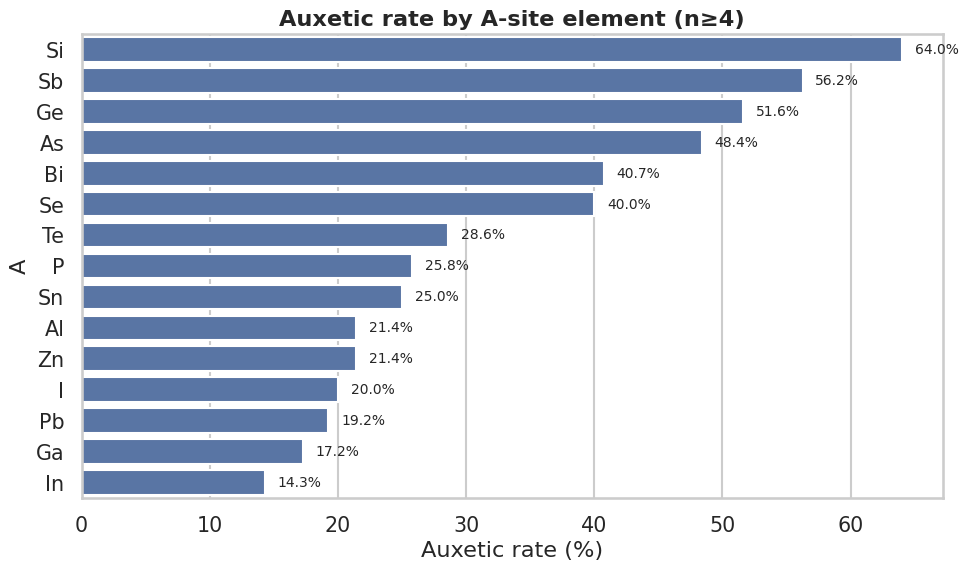

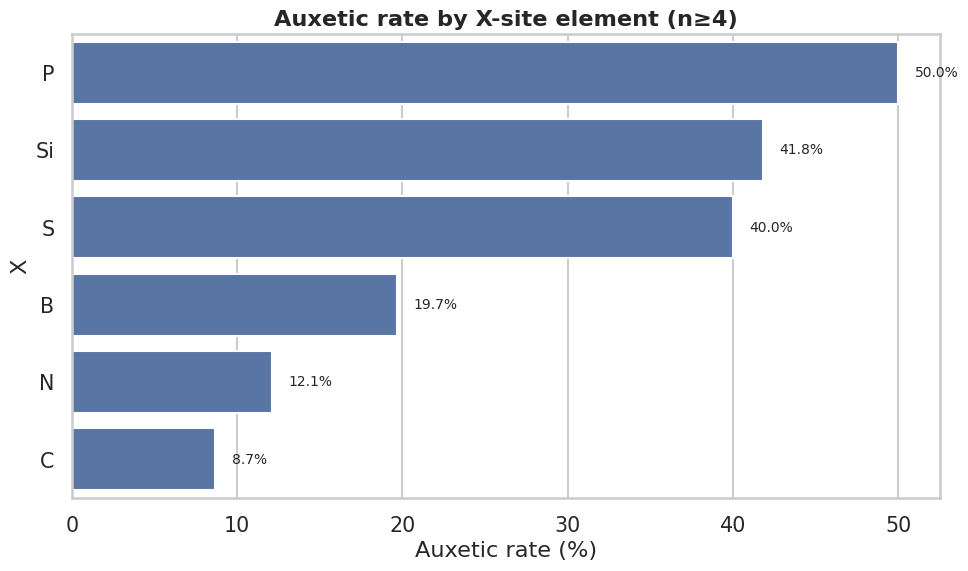

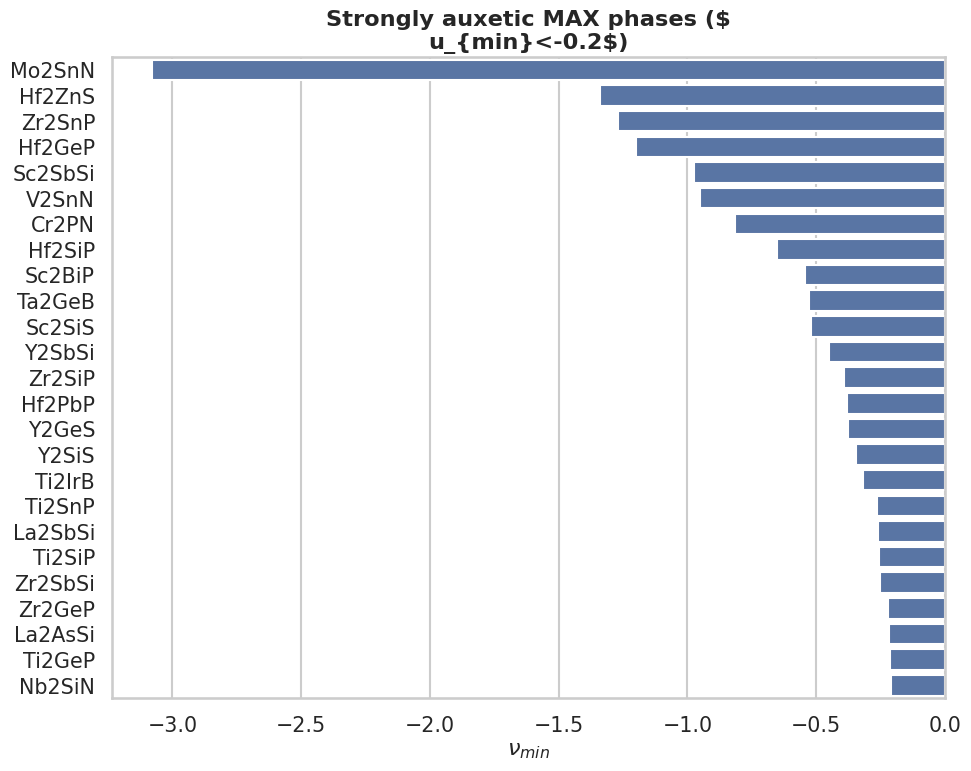

In [69]:
sns.set_theme(context="talk",style="whitegrid",font_scale=0.9)

# 3.1 Class balance
fig,ax=plt.subplots(figsize=(8,5))
counts=pd.Series(y).map({0:"Non-auxetic",1:"Auxetic"}).value_counts().reindex(["Non-auxetic","Auxetic"])
sns.barplot(x=counts.index,y=counts.values,ax=ax)
ax.set_title("MAX Dataset: Auxetic vs Non-auxetic",weight="bold")
ax.set_xlabel(""); ax.set_ylabel("Number of materials")
for i,v in enumerate(counts.values): ax.text(i,v+4,str(v),ha="center",weight="bold")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"v6_class_balance.png"),dpi=220,bbox_inches="tight"); plt.show()

# 3.2 Distribution of nu_min
fig,ax=plt.subplots(figsize=(10,5.5))
sns.histplot(df["nu_min"],bins=45,kde=True,ax=ax)
ax.axvline(0,ls="--",lw=2,label="Auxetic threshold: 0")
ax.set_title(r"Distribution of $\nu_{min}$ in stable MAX phases",weight="bold")
ax.set_xlabel(r"$\nu_{min}$"); ax.set_ylabel("Count")
ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"v6_nu_distribution.png"),dpi=220,bbox_inches="tight"); plt.show()

# 3.3 M-site auxetic rates (only elements with >=4 materials)
for site in ["M","A","X"]:
    tab=df.assign(auxetic=y).groupby(site)["auxetic"].agg(["sum","count"])
    tab["rate"]=100*tab["sum"]/tab["count"]
    tab=tab[tab["count"]>=4].sort_values("rate",ascending=False).head(15)
    fig,ax=plt.subplots(figsize=(10,6))
    sns.barplot(x=tab["rate"].values,y=tab.index,ax=ax,orient="h")
    ax.set_title(f"Auxetic rate by {site}-site element (n≥4)",weight="bold")
    ax.set_xlabel("Auxetic rate (%)"); ax.set_ylabel(site)
    for j,v in enumerate(tab["rate"].values): ax.text(v+1,j,f"{v:.1f}%",va="center",fontsize=10)
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,f"v6_auxetic_rate_{site}.png"),dpi=220,bbox_inches="tight"); plt.show()

# 3.4 Strongly auxetic tail
strong=df[df.nu_min<-0.2].sort_values("nu_min").head(25)
fig,ax=plt.subplots(figsize=(10,8))
sns.barplot(data=strong.reset_index(),x="nu_min",y="material",ax=ax,orient="h")
ax.set_title("Strongly auxetic MAX phases ($\nu_{min}<-0.2$)",weight="bold")
ax.set_xlabel(r"$\nu_{min}$"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"v6_strong_auxetics.png"),dpi=220,bbox_inches="tight"); plt.show()



## 4. مدل‌های طبقه‌بندی و OOF واقعی

برای عدم‌توازن کلاس، نسبت مثبت/منفی حدود 24.5/75.5٪ است. مدل‌ها هم نسخه معمولی و هم برخی نسخه‌های `class_weight="balanced"` را امتحان می‌کنند.



In [70]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

def models():
    return {
        "Logistic":Pipeline([
            ("imp",SimpleImputer(strategy="median")),
            ("scale",StandardScaler()),
            ("model",LogisticRegression(C=0.5,max_iter=3000,class_weight=None,random_state=RANDOM_STATE))]),
        "Logistic_balanced":Pipeline([
            ("imp",SimpleImputer(strategy="median")),
            ("scale",StandardScaler()),
            ("model",LogisticRegression(C=0.5,max_iter=3000,class_weight="balanced",random_state=RANDOM_STATE))]),
        "ExtraTrees":Pipeline([
            ("imp",SimpleImputer(strategy="median")),
            ("model",ExtraTreesClassifier(n_estimators=1200,max_features=0.72,min_samples_leaf=1,
                                           class_weight=None,random_state=RANDOM_STATE,n_jobs=N_JOBS))]),
        "ExtraTrees_balanced":Pipeline([
            ("imp",SimpleImputer(strategy="median")),
            ("model",ExtraTreesClassifier(n_estimators=1200,max_features=0.72,min_samples_leaf=1,
                                           class_weight="balanced",random_state=RANDOM_STATE,n_jobs=N_JOBS))]),
        "RandomForest":Pipeline([
            ("imp",SimpleImputer(strategy="median")),
            ("model",RandomForestClassifier(n_estimators=900,max_features="sqrt",min_samples_leaf=1,
                                             class_weight=None,random_state=RANDOM_STATE,n_jobs=N_JOBS))]),
        "GradientBoosting":Pipeline([
            ("imp",SimpleImputer(strategy="median")),
            ("model",GradientBoostingClassifier(n_estimators=700,learning_rate=0.02,max_depth=3,
                                                  min_samples_leaf=3,random_state=RANDOM_STATE))]),
        "HistGradientBoosting":HistGradientBoostingClassifier(max_iter=600,learning_rate=0.03,max_leaf_nodes=15,
                                                               l2_regularization=1.0,random_state=RANDOM_STATE),
        "XGBoost":XGBClassifier(n_estimators=900,max_depth=3,learning_rate=0.02,subsample=0.85,
                                 colsample_bytree=0.8,min_child_weight=3,reg_alpha=0.05,reg_lambda=2,
                                 objective="binary:logistic",eval_metric="logloss",tree_method="hist",
                                 device="cpu",random_state=RANDOM_STATE,n_jobs=N_JOBS),
        "LightGBM":LGBMClassifier(n_estimators=700,learning_rate=0.025,num_leaves=15,max_depth=-1,
                                   min_child_samples=15,subsample=0.85,colsample_bytree=0.8,
                                   reg_lambda=2.0,verbosity=-1,random_state=RANDOM_STATE,n_jobs=N_JOBS),
        "CatBoost":CatBoostClassifier(iterations=900,depth=5,learning_rate=0.025,loss_function="Logloss",
                                       verbose=False,random_seed=RANDOM_STATE,thread_count=N_JOBS)
    }

def oof_proba(model,Xdf,yv):
    return cross_val_predict(model,Xdf,yv,cv=cv,method="predict_proba",n_jobs=1)[:,1]

def score_binary(yv,p,thr=0.5):
    yp=(p>=thr).astype(int)
    tn,fp,fn,tp=confusion_matrix(yv,yp,labels=[0,1]).ravel()
    return {
        "Threshold":thr,"TN":tn,"FP":fp,"FN":fn,"TP":tp,
        "Accuracy":accuracy_score(yv,yp),"BalancedAccuracy":balanced_accuracy_score(yv,yp),
        "Precision":precision_score(yv,yp,zero_division=0),"Recall":recall_score(yv,yp,zero_division=0),
        "F1":f1_score(yv,yp,zero_division=0),"ROC_AUC":roc_auc_score(yv,p),
        "PR_AUC":average_precision_score(yv,p),"Brier":brier_score_loss(yv,p)
    }

proba_bank={}; base_rows=[]
for name,model in models().items():
    print("Running:",name)
    p=oof_proba(model,X,y)
    proba_bank[name]=p
    base_rows.append({"Model":name,**score_binary(y,p,0.5)})
base_table=pd.DataFrame(base_rows).sort_values("Accuracy",ascending=False)
display(base_table)
base_table.to_csv(os.path.join(OUT_DIR,"v6_classifier_base_results.csv"),index=False)



Running: Logistic
Running: Logistic_balanced
Running: ExtraTrees
Running: ExtraTrees_balanced
Running: RandomForest
Running: GradientBoosting
Running: HistGradientBoosting
Running: XGBoost
Running: LightGBM
Running: CatBoost


,Model,Threshold,TN,FP,FN,TP,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
6,HistGradientBoosting,0.5,387,26,48,86,0.864717,0.789419,0.767857,0.641791,0.699187,0.840320,0.767734,0.112451
7,XGBoost,0.5,392,21,53,81,0.864717,0.776815,0.794118,0.604478,0.686441,0.853366,0.761468,0.109453
9,CatBoost,0.5,390,23,57,77,0.853748,0.759468,0.770000,0.574627,0.658120,0.855372,0.776215,0.111101
8,LightGBM,0.5,388,25,55,79,0.853748,0.764510,0.759615,0.589552,0.663866,0.847891,0.763917,0.117355
4,RandomForest,0.5,393,20,60,74,0.853748,0.751906,0.787234,0.552239,0.649123,0.853086,0.769307,0.109249
3,ExtraTrees_balanced,0.5,381,32,49,85,0.851920,0.778423,0.726496,0.634328,0.677291,0.846410,0.770482,0.111938
5,GradientBoosting,0.5,385,28,59,75,0.840951,0.745952,0.728155,0.559701,0.632911,0.835785,0.746932,0.120680
2,ExtraTrees,0.5,372,41,48,86,0.837294,0.771259,0.677165,0.641791,0.659004,0.845072,0.769857,0.115068
0,Logistic,0.5,384,29,64,70,0.829982,0.726085,0.707071,0.522388,0.600858,0.822305,0.695038,0.128080
1,Logistic_balanced,0.5,321,92,40,94,0.758684,0.739366,0.505376,0.701493,0.587500,0.816125,0.663372,0.164446


## 5. انتخاب آستانه بدون leakage

آستانه 0.5 همیشه بهترین threshold نیست. برای هر outer fold، threshold با فقط داده‌های train همان fold انتخاب می‌شود و بعد روی validation fold اعمال می‌گردد. معیار اصلی انتخاب، Accuracy است؛ F1 و Recall هم برای بررسی trade-off نگه داشته می‌شوند.



In [71]:
# Nested threshold selection for the leading models
THRESHOLDS=np.linspace(0.15,0.85,141)

def nested_threshold_oof(model,Xdf,yv,objective="accuracy"):
    outer=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
    p_oof=np.zeros(len(yv)); chosen=[]
    for tr,te in outer.split(Xdf,yv):
        Xtr,Xte=Xdf.iloc[tr],Xdf.iloc[te]; ytr,yte=yv[tr],yv[te]
        p_tr=cross_val_predict(model,Xtr,ytr,cv=StratifiedKFold(n_splits=4,shuffle=True,random_state=RANDOM_STATE),
                                method="predict_proba",n_jobs=1)[:,1]
        vals=[]
        for t in THRESHOLDS:
            yp=(p_tr>=t).astype(int)
            if objective=="accuracy": val=accuracy_score(ytr,yp)
            elif objective=="f1": val=f1_score(ytr,yp,zero_division=0)
            else: val=balanced_accuracy_score(ytr,yp)
            vals.append(val)
        tbest=float(THRESHOLDS[int(np.argmax(vals))])
        model2=model
        model2.fit(Xtr,ytr)
        p_oof[te]=model2.predict_proba(Xte)[:,1]
        chosen.append(tbest)
    return p_oof,float(np.mean(chosen)),chosen

lead_names=base_table.head(5)["Model"].tolist()
tuned_rows=[]; tuned_bank={}
for name in lead_names:
    p,tmean,ts=nested_threshold_oof(models()[name],X,y,objective="accuracy")
    tuned_bank[name]=p
    tuned_rows.append({"Model":name,"MeanThreshold":tmean,**score_binary(y,p,tmean)})
tuned_table=pd.DataFrame(tuned_rows).sort_values("Accuracy",ascending=False)
display(tuned_table)
tuned_table.to_csv(os.path.join(OUT_DIR,"v6_nested_threshold_results.csv"),index=False)



,Model,MeanThreshold,Threshold,TN,FP,FN,TP,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,HistGradientBoosting,0.595,0.595,391,22,51,83,0.866545,0.783067,0.790476,0.619403,0.694561,0.840320,0.767734,0.112451
1,XGBoost,0.504,0.504,393,20,53,81,0.866545,0.778026,0.801980,0.604478,0.689362,0.853366,0.761468,0.109453
4,RandomForest,0.525,0.525,397,16,61,73,0.859232,0.753018,0.820225,0.544776,0.654709,0.853086,0.769307,0.109249
2,CatBoost,0.559,0.559,393,20,58,76,0.857404,0.759369,0.791667,0.567164,0.660870,0.855372,0.776215,0.111101
3,LightGBM,0.579,0.579,392,21,57,77,0.857404,0.761890,0.785714,0.574627,0.663793,0.847891,0.763917,0.117355


## 6. Ensemble: probability averaging بین مدل‌های مکمل

به‌جای بهینه‌سازی وزن روی همان OOF و ایجاد خطر overfitting، چند ensemble ثابت و قابل تفسیر ساخته می‌شود. همچنین همبستگی prediction errorها بررسی می‌شود تا ببینیم آیا مدل‌ها واقعاً اطلاعات مکمل می‌آورند.



In [72]:
# Error/prediction correlations among best single models
sel=base_table.sort_values("ROC_AUC",ascending=False).head(5)["Model"].tolist()
prob_df=pd.DataFrame({n:proba_bank[n] for n in sel})
err_df=pd.DataFrame({n:y-proba_bank[n] for n in sel})
print("Selected:",sel)
display(err_df.corr().round(3))

ensemble_defs={
    "Ensemble_top3_equal":sel[:3],
    "Ensemble_top5_equal":sel[:5]
}
ens_rows=[]; ens_bank={}
for ename,names in ensemble_defs.items():
    p=prob_df[names].mean(axis=1).values
    ens_bank[ename]=p
    row={"Model":ename,"Components":" + ".join(names),**score_binary(y,p,0.5)}
    ens_rows.append(row)
ensemble_table=pd.DataFrame(ens_rows).sort_values("Accuracy",ascending=False)
display(ensemble_table)
ensemble_table.to_csv(os.path.join(OUT_DIR,"v6_ensemble_results.csv"),index=False)



Selected: ['CatBoost', 'XGBoost', 'RandomForest', 'LightGBM', 'ExtraTrees_balanced']


,CatBoost,XGBoost,RandomForest,LightGBM,ExtraTrees_balanced
CatBoost,1.000,0.956,0.954,0.959,0.945
XGBoost,0.956,1.000,0.957,0.969,0.921
RandomForest,0.954,0.957,1.000,0.932,0.948
LightGBM,0.959,0.969,0.932,1.000,0.930
ExtraTrees_balanced,0.945,0.921,0.948,0.930,1.000


,Model,Components,Threshold,TN,FP,FN,TP,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,Ensemble_top3_equal,CatBoost + XGBoost + RandomForest,0.5,393,20,57,77,0.859232,0.763100,0.793814,0.574627,0.666667,0.858534,0.777613,0.106387
1,Ensemble_top5_equal,CatBoost + XGBoost + RandomForest + LightGBM +...,0.5,391,22,57,77,0.855576,0.760679,0.777778,0.574627,0.660944,0.856763,0.780584,0.106804


## 7. نمودار ROC و Precision–Recall برای بهترین مدل‌ها



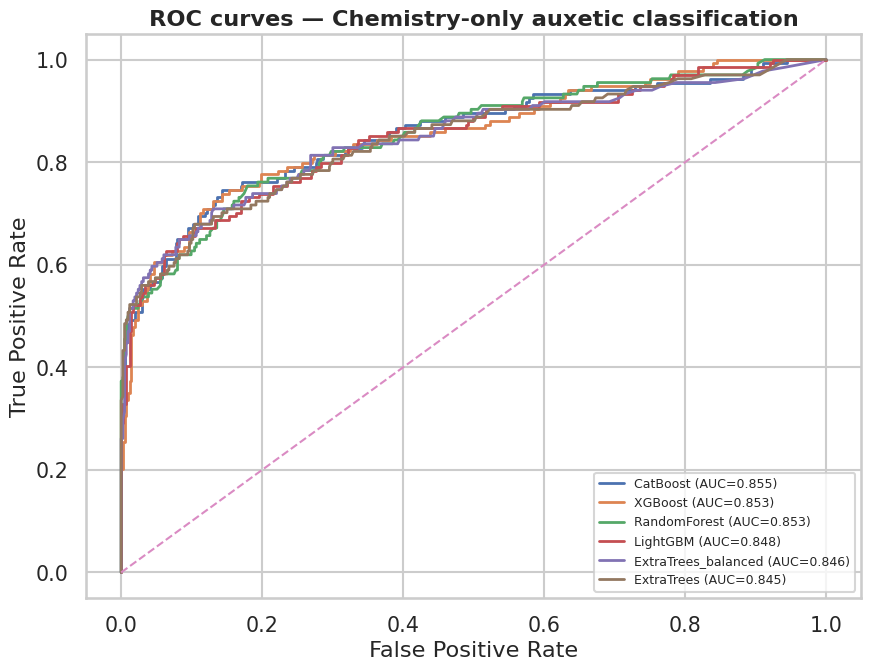

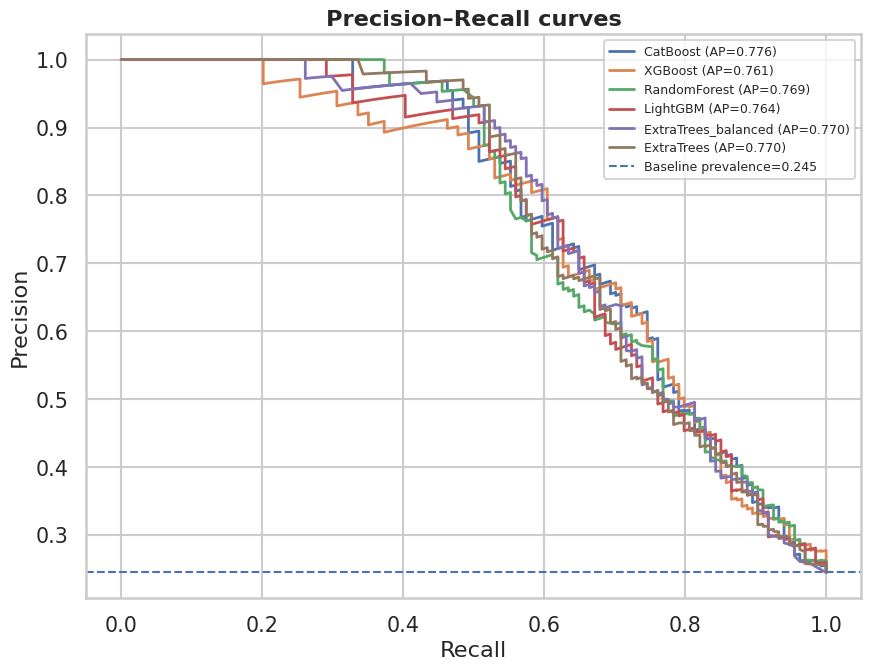

In [73]:
plot_names=base_table.sort_values("ROC_AUC",ascending=False).head(6)["Model"].tolist()
fig,ax=plt.subplots(figsize=(9,7))
for name in plot_names:
    p=proba_bank[name]; fpr,tpr,_=roc_curve(y,p)
    ax.plot(fpr,tpr,lw=2,label=f"{name} (AUC={roc_auc_score(y,p):.3f})")
ax.plot([0,1],[0,1],"--",lw=1.5)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves — Chemistry-only auxetic classification",weight="bold")
ax.legend(fontsize=9); plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"v6_ROC_curves.png"),dpi=220,bbox_inches="tight"); plt.show()

fig,ax=plt.subplots(figsize=(9,7))
base_rate=y.mean()
for name in plot_names:
    p=proba_bank[name]; prec,rec,_=precision_recall_curve(y,p)
    ax.plot(rec,prec,lw=2,label=f"{name} (AP={average_precision_score(y,p):.3f})")
ax.axhline(base_rate,ls="--",lw=1.5,label=f"Baseline prevalence={base_rate:.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision–Recall curves",weight="bold")
ax.legend(fontsize=9); plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"v6_PR_curves.png"),dpi=220,bbox_inches="tight"); plt.show()



## 8. Confusion matrix + عملکرد مدل منتخب

مدل منتخب برای **Accuracy** از OOF واقعی انتخاب می‌شود؛ سپس confusion matrix و جزئیات classification report چاپ می‌شوند.



,Model,Threshold,TN,FP,FN,TP,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
6,HistGradientBoosting,0.5,387,26,48,86,0.864717,0.789419,0.767857,0.641791,0.699187,0.840320,0.767734,0.112451
7,XGBoost,0.5,392,21,53,81,0.864717,0.776815,0.794118,0.604478,0.686441,0.853366,0.761468,0.109453
10,Ensemble_top3_equal,0.5,393,20,57,77,0.859232,0.763100,0.793814,0.574627,0.666667,0.858534,0.777613,0.106387
11,Ensemble_top5_equal,0.5,391,22,57,77,0.855576,0.760679,0.777778,0.574627,0.660944,0.856763,0.780584,0.106804
8,LightGBM,0.5,388,25,55,79,0.853748,0.764510,0.759615,0.589552,0.663866,0.847891,0.763917,0.117355
9,CatBoost,0.5,390,23,57,77,0.853748,0.759468,0.770000,0.574627,0.658120,0.855372,0.776215,0.111101
4,RandomForest,0.5,393,20,60,74,0.853748,0.751906,0.787234,0.552239,0.649123,0.853086,0.769307,0.109249
3,ExtraTrees_balanced,0.5,381,32,49,85,0.851920,0.778423,0.726496,0.634328,0.677291,0.846410,0.770482,0.111938
5,GradientBoosting,0.5,385,28,59,75,0.840951,0.745952,0.728155,0.559701,0.632911,0.835785,0.746932,0.120680
2,ExtraTrees,0.5,372,41,48,86,0.837294,0.771259,0.677165,0.641791,0.659004,0.845072,0.769857,0.115068


BEST OOF MODEL: HistGradientBoosting
              precision    recall  f1-score   support

 Non-auxetic     0.8897    0.9370    0.9127       413
     Auxetic     0.7679    0.6418    0.6992       134

    accuracy                         0.8647       547
   macro avg     0.8288    0.7894    0.8060       547
weighted avg     0.8598    0.8647    0.8604       547



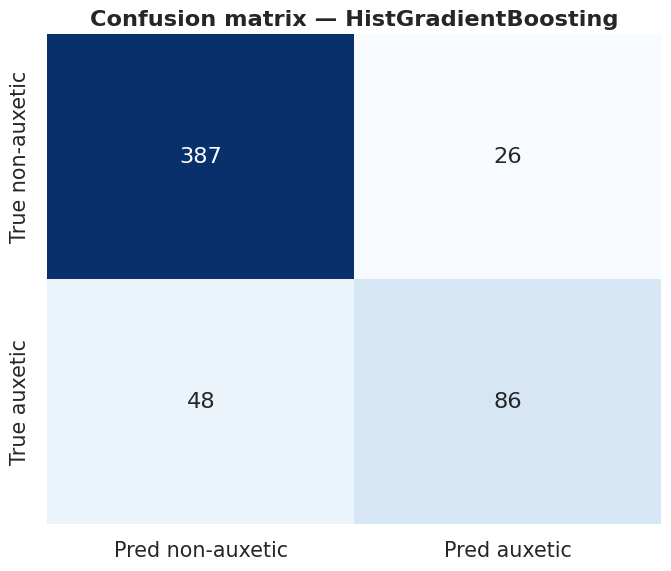

In [74]:
all_candidate=[]
for name,p in {**proba_bank,**ens_bank}.items():
    all_candidate.append({"Model":name,**score_binary(y,p,0.5)})
all_candidate=pd.DataFrame(all_candidate).sort_values(["Accuracy","F1","ROC_AUC"],ascending=False)
display(all_candidate)
best_name=all_candidate.iloc[0]["Model"]
best_p=(proba_bank|ens_bank)[best_name]
best_thr=0.5
print("BEST OOF MODEL:",best_name)
print(classification_report(y,(best_p>=best_thr).astype(int),target_names=["Non-auxetic","Auxetic"],digits=4))

cm=confusion_matrix(y,(best_p>=best_thr).astype(int))
fig,ax=plt.subplots(figsize=(7,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,xticklabels=["Pred non-auxetic","Pred auxetic"],yticklabels=["True non-auxetic","True auxetic"],ax=ax)
ax.set_title(f"Confusion matrix — {best_name}",weight="bold")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"v6_confusion_matrix.png"),dpi=220,bbox_inches="tight"); plt.show()



## 9. آستانه‌گذاری برای کاربرد screening

اگر هدف **پیدا کردن حداکثری مواد auxetic** باشد، Accuracy به‌تنهایی کافی نیست. این نمودار نشان می‌دهد با پایین آوردن threshold، Recall چگونه در برابر Precision تغییر می‌کند.



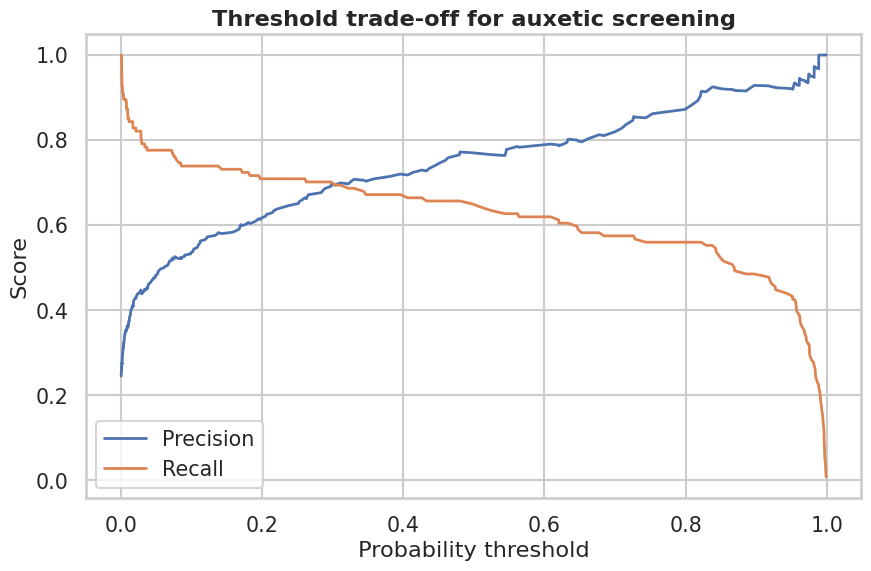

,Threshold,TN,FP,FN,TP,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,0.20,355,58,39,95,0.822669,0.784260,0.620915,0.708955,0.662021,0.84032,0.767734,0.112451
1,0.25,362,51,39,95,0.835466,0.792734,0.650685,0.708955,0.678571,0.84032,0.767734,0.112451
2,0.30,372,41,41,93,0.850091,0.797378,0.694030,0.694030,0.694030,0.84032,0.767734,0.112451
3,0.35,376,37,44,90,0.851920,0.791027,0.708661,0.671642,0.689655,0.84032,0.767734,0.112451
4,0.40,378,35,45,89,0.853748,0.789717,0.717742,0.664179,0.689922,0.84032,0.767734,0.112451
5,0.45,383,30,46,88,0.861060,0.792039,0.745763,0.656716,0.698413,0.84032,0.767734,0.112451
6,0.50,387,26,48,86,0.864717,0.789419,0.767857,0.641791,0.699187,0.84032,0.767734,0.112451
7,0.55,390,23,50,84,0.866545,0.785588,0.785047,0.626866,0.697095,0.84032,0.767734,0.112451
8,0.60,391,22,51,83,0.866545,0.783067,0.790476,0.619403,0.694561,0.84032,0.767734,0.112451
9,0.65,393,20,56,78,0.861060,0.766832,0.795918,0.582090,0.672414,0.84032,0.767734,0.112451


In [75]:
prec,rec,thr=precision_recall_curve(y,best_p)
fig,ax=plt.subplots(figsize=(9,6))
ax.plot(thr,prec[:-1],label="Precision",lw=2)
ax.plot(thr,rec[:-1],label="Recall",lw=2)
ax.set_xlabel("Probability threshold"); ax.set_ylabel("Score")
ax.set_title("Threshold trade-off for auxetic screening",weight="bold")
ax.legend(); plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"v6_threshold_tradeoff.png"),dpi=220,bbox_inches="tight"); plt.show()

threshold_rows=[]
for t in np.arange(0.20,0.81,0.05):
    threshold_rows.append({"Threshold":round(float(t),2),**score_binary(y,best_p,float(t))})
thr_table=pd.DataFrame(threshold_rows)
display(thr_table)
thr_table.to_csv(os.path.join(OUT_DIR,"v6_threshold_tradeoff_table.csv"),index=False)



## 10. Calibration و اعتماد مدل

احتمال پیش‌بینی‌شده باید تا حد ممکن با احتمال واقعی auxeticity سازگار باشد. این بخش calibration curve و Brier score را نشان می‌دهد.



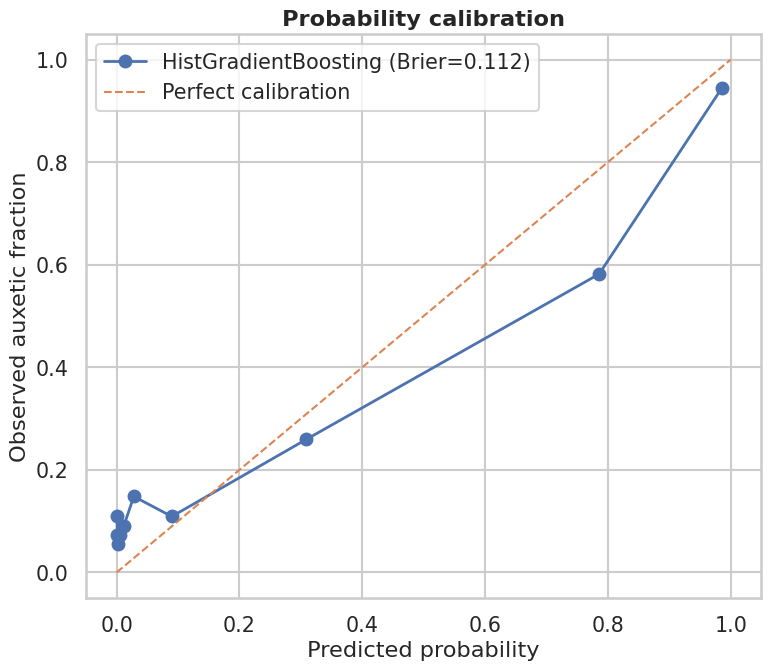

In [76]:
fig,ax=plt.subplots(figsize=(8,7))
frac,pos=calibration_curve(y,best_p,n_bins=10,strategy="quantile")
ax.plot(pos,frac,"o-",lw=2,label=f"{best_name} (Brier={brier_score_loss(y,best_p):.3f})")
ax.plot([0,1],[0,1],"--",lw=1.5,label="Perfect calibration")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed auxetic fraction")
ax.set_title("Probability calibration",weight="bold")
ax.legend(); plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"v6_calibration.png"),dpi=220,bbox_inches="tight"); plt.show()



## 11. Feature importance برای تفسیر شیمیایی

برای مدل tree-based منتخب، اهمیت permutation روی OOF prediction به‌صورت fold-based بررسی می‌شود. این قسمت فقط **تفسیر شیمیایی** است و هیچ claim مکانیزمی فراتر از داده ارائه نمی‌کند.



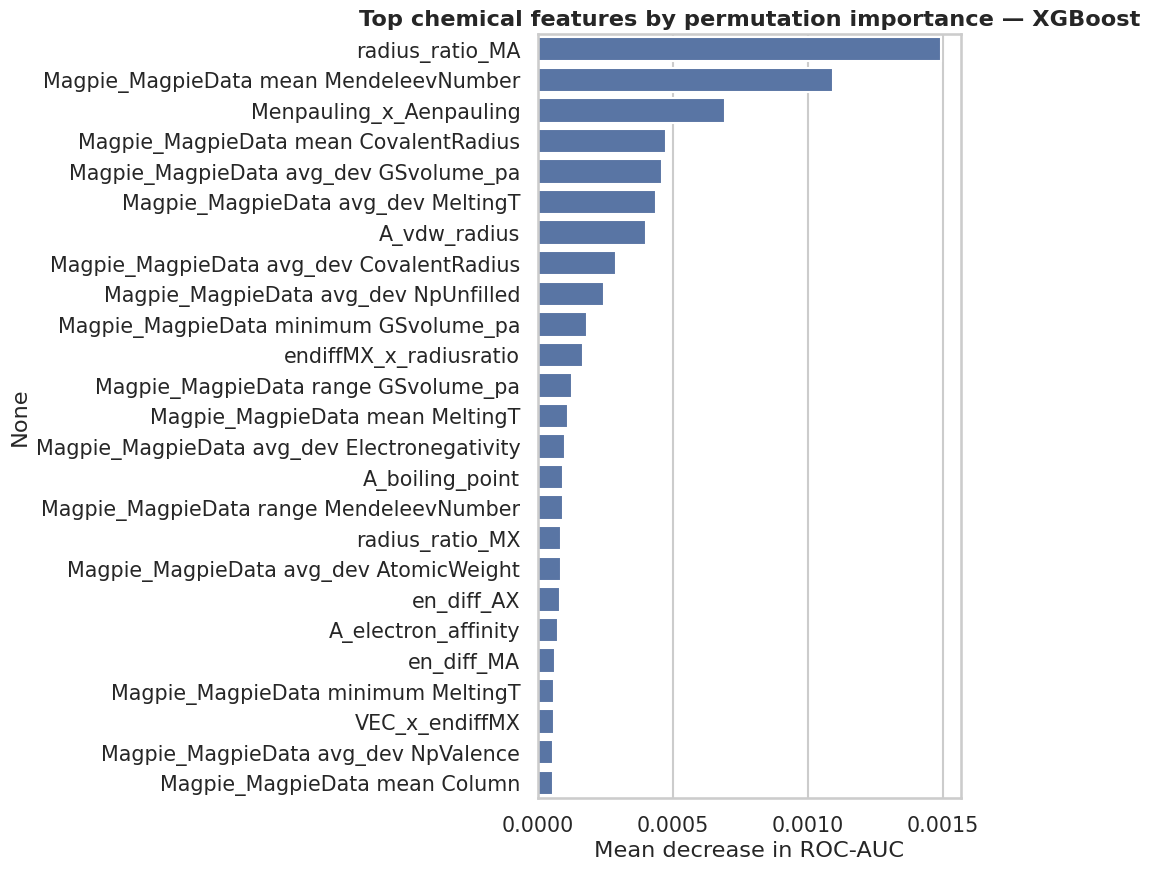

,importance
radius_ratio_MA,0.001495
Magpie_MagpieData mean MendeleevNumber,0.001095
Menpauling_x_Aenpauling,0.000693
Magpie_MagpieData mean CovalentRadius,0.000477
Magpie_MagpieData avg_dev GSvolume_pa,0.000461
Magpie_MagpieData avg_dev MeltingT,0.000438
A_vdw_radius,0.000402
Magpie_MagpieData avg_dev CovalentRadius,0.000289
Magpie_MagpieData avg_dev NpUnfilled,0.000244
Magpie_MagpieData minimum GSvolume_pa,0.000183


In [77]:
# Find best tree model among available base models
candidate_tree=[n for n in base_table.sort_values("Accuracy",ascending=False)["Model"] if n in ["ExtraTrees","ExtraTrees_balanced","RandomForest","GradientBoosting","XGBoost","LightGBM","CatBoost"]]
if candidate_tree:
    imp_name=candidate_tree[0]
    model=models()[imp_name]
    model.fit(X,y)
    perm=permutation_importance(model,X,y,n_repeats=8,random_state=RANDOM_STATE,scoring="roc_auc",n_jobs=N_JOBS)
    im=pd.Series(perm.importances_mean,index=X.columns).sort_values(ascending=False).head(25)
    fig,ax=plt.subplots(figsize=(10,9))
    sns.barplot(x=im.values,y=im.index,ax=ax,orient="h")
    ax.set_title(f"Top chemical features by permutation importance — {imp_name}",weight="bold")
    ax.set_xlabel("Mean decrease in ROC-AUC")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"v6_feature_importance.png"),dpi=220,bbox_inches="tight"); plt.show()
    im.to_csv(os.path.join(OUT_DIR,"v6_top_feature_importance.csv"))
    display(im.to_frame("importance"))



## 12. OOD ارزیابی سخت‌گیرانه با GroupKFold بر اساس عنصر M

این تست می‌پرسد آیا مدل می‌تواند برای خانواده‌ای از عناصر M که در train دیده نشده، auxeticity را تشخیص دهد. این معیار معمولاً سخت‌تر از random Stratified CV است و برای مقاله بسیار مهم است.



In [78]:
group=df["M"].values
valid_groups=group
outer=GroupKFold(n_splits=min(5,len(np.unique(group))))
# Use the strongest single model under random CV for a harder OOD estimate.
ood_model=models()[best_name] if best_name in models() else models()[base_table.iloc[0]["Model"]]
ood_p=np.zeros(len(y))
for tr,te in outer.split(X,y,groups=valid_groups):
    # clone via sklearn-friendly fit fresh object
    import copy
    m=copy.deepcopy(ood_model)
    m.fit(X.iloc[tr],y[tr])
    ood_p[te]=m.predict_proba(X.iloc[te])[:,1]

ood_metrics=score_binary(y,ood_p,0.5)
print("GroupKFold-by-M OOD metrics")
print(ood_metrics)
pd.DataFrame([{"Evaluation":"GroupKFold by M",**ood_metrics}]).to_csv(os.path.join(OUT_DIR,"v6_groupkfold_M.csv"),index=False)



GroupKFold-by-M OOD metrics
{'Threshold': 0.5, 'TN': np.int64(380), 'FP': np.int64(33), 'FN': np.int64(54), 'TP': np.int64(80), 'Accuracy': 0.8409506398537477, 'BalancedAccuracy': np.float64(0.7585558888366882), 'Precision': 0.7079646017699115, 'Recall': 0.5970149253731343, 'F1': 0.6477732793522267, 'ROC_AUC': np.float64(0.8342669220483538), 'PR_AUC': np.float64(0.7274967752393153), 'Brier': np.float64(0.12513543722348255)}


## 13. تحلیل خطا: کدام مواد auxetic از دست می‌روند؟



In [79]:
err=df[["M","A","X","nu_min"]].copy()
err["actual_auxetic"]=y.astype(bool)
err["p_auxetic"]=best_p
err["pred_auxetic"]=(best_p>=0.5)
err["correct"]=(err["actual_auxetic"]==err["pred_auxetic"])
missed=err[(err.actual_auxetic)&(~err.pred_auxetic)].sort_values("p_auxetic")
false_pos=err[(~err.actual_auxetic)&(err.pred_auxetic)].sort_values("p_auxetic",ascending=False)
print("Missed true auxetics (FN):",len(missed))
display(missed.head(25))
print("False positives (FP):",len(false_pos))
display(false_pos.head(25))
missed.to_csv(os.path.join(OUT_DIR,"v6_false_negatives.csv"))
false_pos.to_csv(os.path.join(OUT_DIR,"v6_false_positives.csv"))



Missed true auxetics (FN): 48


,M,A,X,nu_min,actual_auxetic,p_auxetic,pred_auxetic,correct
material,,,,,,,,
V2CdC,V,Cd,C,-0.172,True,0.000420,False,False
Sc2AsN,Sc,As,N,-0.180,True,0.000657,False,False
Zr2BiN,Zr,Bi,N,-0.090,True,0.000684,False,False
Ti2IrB,Ti,Ir,B,-0.319,True,0.000700,False,False
Hf2BiN,Hf,Bi,N,-0.111,True,0.000730,False,False
Y2GeS,Y,Ge,S,-0.375,True,0.000753,False,False
Pt2CdSi,Pt,Cd,Si,-0.121,True,0.000912,False,False
La2SiS,La,Si,S,-0.054,True,0.001158,False,False
La2GeS,La,Ge,S,-0.157,True,0.001245,False,False


False positives (FP): 26


,M,A,X,nu_min,actual_auxetic,p_auxetic,pred_auxetic,correct
material,,,,,,,,
Ti2BiS,Ti,Bi,S,0.042,False,0.988758,True,False
Hf2TeP,Hf,Te,P,0.075,False,0.982254,True,False
Ti2PB,Ti,P,B,0.002,False,0.973557,True,False
Ti2AsS,Ti,As,S,0.009,False,0.961247,True,False
Ti2GeB,Ti,Ge,B,0.137,False,0.951960,True,False
Cr2SnN,Cr,Sn,N,0.183,False,0.885736,True,False
Co2SnP,Co,Sn,P,0.114,False,0.829195,True,False
Hf2TlS,Hf,Tl,S,0.050,False,0.821042,True,False
Hf2TlP,Hf,Tl,P,0.016,False,0.817428,True,False


## 14. Heatmap شیمیایی برای سه جایگاه M/A/X

نرخ auxeticity در ترکیب‌های پرتکرار M×A نیز بررسی می‌شود تا الگوهای احتمالی شیمیایی دیده شوند.



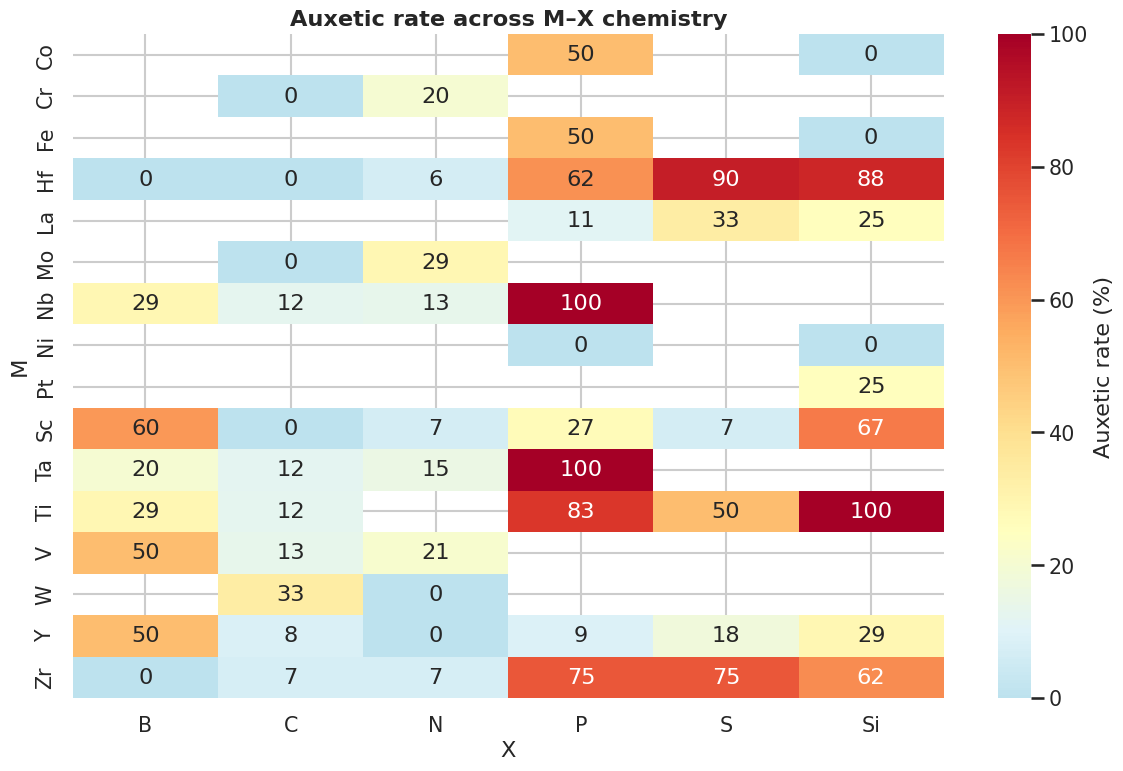

In [80]:
pivot=df.assign(auxetic=y).pivot_table(index="M",columns="X",values="auxetic",aggfunc="mean")
# retain rows/cols with enough samples
row_ok=df.groupby("M").size(); col_ok=df.groupby("X").size()
pivot=pivot.loc[[i for i in pivot.index if row_ok.get(i,0)>=4]]
pivot=pivot[[j for j in pivot.columns if col_ok.get(j,0)>=4]]
if pivot.shape[0] and pivot.shape[1]:
    fig,ax=plt.subplots(figsize=(12,8))
    sns.heatmap(100*pivot,cmap="RdYlBu_r",annot=True,fmt=".0f",center=25,cbar_kws={"label":"Auxetic rate (%)"},ax=ax)
    ax.set_title("Auxetic rate across M–X chemistry",weight="bold")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,"v6_M_X_auxetic_heatmap.png"),dpi=220,bbox_inches="tight"); plt.show()



## 15. جمع‌بندی نهایی

این سلول سه چیز را جداگانه گزارش می‌کند:
1. بهترین Accuracy در random OOF؛
2. بهترین Recall/F1 برای screening؛
3. سخت‌ترین GroupKFold-by-M نتیجه.

این تفکیک مهم است، چون **Accuracy بالا الزاماً به معنی کشف همه مواد auxetic نیست.**



In [81]:
all_results=pd.concat([
    base_table.assign(Source="Base"),
    ensemble_table.assign(Source="Ensemble")
],ignore_index=True,sort=False)
best_acc=all_results.sort_values(["Accuracy","F1"],ascending=False).iloc[0]
best_f1=all_results.sort_values(["F1","Recall"],ascending=False).iloc[0]

print("="*88)
print("MAX AUXETIC CLASSIFICATION — CHEMISTRY ONLY")
print("="*88)
print(f"Dataset: {len(df)}")
print(f"Chemical features: {X.shape[1]}")
print(f"Auxetic: {int(y.sum())} / {len(y)} ({100*y.mean():.2f}%)")
print("-"*88)
print("Best OOF Accuracy model:",best_acc["Model"])
print("Accuracy:",round(float(best_acc["Accuracy"]),4))
print("Precision:",round(float(best_acc["Precision"]),4))
print("Recall:",round(float(best_acc["Recall"]),4))
print("F1:",round(float(best_acc["F1"]),4))
print("ROC-AUC:",round(float(best_acc["ROC_AUC"]),4))
print("PR-AUC:",round(float(best_acc["PR_AUC"]),4))
print("-"*88)
print("Best F1 model:",best_f1["Model"],"| F1=",round(float(best_f1["F1"]),4),"| Recall=",round(float(best_f1["Recall"]),4))
print("GroupKFold-by-M Accuracy:",round(float(ood_metrics["Accuracy"]),4))
print("GroupKFold-by-M Recall:",round(float(ood_metrics["Recall"]),4))
print("="*88)

all_results.to_csv(os.path.join(OUT_DIR,"v6_all_classifier_results.csv"),index=False)
summary=pd.DataFrame([{
    "Dataset_N":len(df),"Features":X.shape[1],"Auxetic_N":int(y.sum()),"Auxetic_percent":100*y.mean(),
    "Best_accuracy_model":best_acc["Model"],"Best_accuracy":best_acc["Accuracy"],
    "Best_accuracy_precision":best_acc["Precision"],"Best_accuracy_recall":best_acc["Recall"],
    "Best_accuracy_F1":best_acc["F1"],"Best_accuracy_ROC_AUC":best_acc["ROC_AUC"],"Best_accuracy_PR_AUC":best_acc["PR_AUC"],
    "OOD_GroupKFold_M_accuracy":ood_metrics["Accuracy"],"OOD_GroupKFold_M_recall":ood_metrics["Recall"]
}])
summary.to_csv(os.path.join(OUT_DIR,"v6_final_summary.csv"),index=False)
display(summary)



MAX AUXETIC CLASSIFICATION — CHEMISTRY ONLY
Dataset: 547
Chemical features: 186
Auxetic: 134 / 547 (24.50%)
----------------------------------------------------------------------------------------
Best OOF Accuracy model: HistGradientBoosting
Accuracy: 0.8647
Precision: 0.7679
Recall: 0.6418
F1: 0.6992
ROC-AUC: 0.8403
PR-AUC: 0.7677
----------------------------------------------------------------------------------------
Best F1 model: HistGradientBoosting | F1= 0.6992 | Recall= 0.6418
GroupKFold-by-M Accuracy: 0.841
GroupKFold-by-M Recall: 0.597


,Dataset_N,Features,Auxetic_N,Auxetic_percent,Best_accuracy_model,Best_accuracy,Best_accuracy_precision,Best_accuracy_recall,Best_accuracy_F1,Best_accuracy_ROC_AUC,Best_accuracy_PR_AUC,OOD_GroupKFold_M_accuracy,OOD_GroupKFold_M_recall
0,547,186,134,24.497258,HistGradientBoosting,0.864717,0.767857,0.641791,0.699187,0.84032,0.767734,0.840951,0.597015


## خروجی‌های اصلی

فایل‌های PNG و CSV در `OUT_DIR` ذخیره می‌شوند، از جمله:

- `v6_class_balance.png`
- `v6_nu_distribution.png`
- `v6_auxetic_rate_M.png`, `v6_auxetic_rate_A.png`, `v6_auxetic_rate_X.png`
- `v6_strong_auxetics.png`
- `v6_ROC_curves.png`
- `v6_PR_curves.png`
- `v6_confusion_matrix.png`
- `v6_threshold_tradeoff.png`
- `v6_calibration.png`
- `v6_feature_importance.png`
- `v6_M_X_auxetic_heatmap.png`
- `v6_final_summary.csv`

**مبنای علمی گزارش:** مدل فقط از chemistry descriptors استفاده می‌کند؛ هیچ feature ساختاری، POSCAR هندسی یا Cij وارد classifier نشده است.

